# 05 — Ablation: baseline 을 해부하고 더 가볍게 다시 만들기

[03](03_feature_engineering.ipynb) 은 40개 그룹 파일럿으로 "무엇이 효과가 있나"를 봤고,
그 결론 하나가 전체 규모에서 뒤집히는 것도 겪었다.
이 노트북은 **같은 질문을 512개 그룹 전체에서, 처음부터 제대로 설계해서** 다시 묻는다.

- 실험 스크립트: [`experiments/simplify/simplify.py`](../experiments/simplify/simplify.py) (약 72분)
- 이 노트북은 그 **산출물(`outputs/`)만 읽는다** — 몇 초면 끝난다 ([04](04_model_diagnostics.ipynb) 와 같은 방식)

## 이 노트북에서 배우는 것

**Ablation study(절제 실험)** — 시스템에서 부품을 하나씩 떼어 내고 성능 변화를 재는 방법.
"이 부품이 필요한가"를 묻는 가장 정직한 방법이지만, 설계를 잘못하면 잡음을 결론으로 착각한다.

| 설계 원칙 | 이 실험에서 어떻게 지켰나 |
|---|---|
| **한 번에 하나만 바꾼다** | 설정 하나 = baseline 에서 스위치 하나만 끈 것 |
| **대조군이 원본을 재현해야 한다** | `baseline_probe` 가 baseline 의 QDA 를 **비트 단위로** 재현하는지 검사 |
| **같은 데이터·같은 분할로 비교한다** | 512그룹 전체, fold 시드 고정 → 그룹별 대응 비교 |
| **효과 크기를 잡음과 함께 본다** | 그룹별 차이의 평균 ± 95% CI, 이긴 그룹 수 |
| **지표를 하나만 믿지 않는다** | pooled AUC(대회 지표)와 그룹별 AUC 를 나란히 |

## 두 질문
1. **해부** — baseline 의 부품 중 무엇이 성능을 만드는가?
2. **단순화** — 결정적인 부품만 남기면 같은 점수가 나오는가?

> 실행 전제: `python experiments/simplify/simplify.py` 와
> `python experiments/simplify/simplify.py --phase followup --tag followup` 을 완주해
> `experiments/simplify/outputs/` 에 `simplify_*`, `followup_*` 산출물이 있어야 한다.

In [1]:
import json
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy import stats
from sklearn.metrics import roc_auc_score

PROJECT_DIR = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "loader.py").exists()
)
sys.path.insert(0, str(PROJECT_DIR))

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
_available = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"):
    if _font in _available:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

OUT = PROJECT_DIR / "experiments" / "simplify" / "outputs"
BASE_OUT = PROJECT_DIR / "experiments" / "baseline" / "outputs"
for f in ("simplify_metrics.json", "followup_metrics.json", "simplify_per_group_auc.csv", "followup_per_group_auc.csv"):
    if not (OUT / f).exists():
        raise FileNotFoundError(f"{OUT / f} 가 없습니다. simplify.py 를 먼저 실행하세요 (README 참고).")

m1 = json.loads((OUT / "simplify_metrics.json").read_text(encoding="utf-8"))
m2 = json.loads((OUT / "followup_metrics.json").read_text(encoding="utf-8"))
pg1 = pd.read_csv(OUT / "simplify_per_group_auc.csv", index_col=0)
pg2 = pd.read_csv(OUT / "followup_per_group_auc.csv", index_col=0)
pg = pd.concat([pg1, pg2.drop(columns=["baseline_final", "baseline_qda_avg4"])], axis=1)
base_metrics = json.loads((BASE_OUT / "baseline_metrics.json").read_text(encoding="utf-8"))

# 설정별 결과를 하나의 표로 (1차 + 후속)
results = {**m1["results"], **m2["results"]}
combos = {**m1["combos"], **m2["combos"]}
REF_FINAL = m1["reference"]["baseline_final_auc"]
REF_QDA1 = m1["reference"]["baseline_qda_single_kmeans_s1"]
print(f"설정 {len(results)}개, 조합 {len(combos)}개, 그룹 {len(pg)}개")
print(f"baseline 최종 AUC = {REF_FINAL:.6f}, baseline QDA 단일(kmeans, seed1) = {REF_QDA1:.6f}")

설정 40개, 조합 8개, 그룹 512개
baseline 최종 AUC = 0.949605, baseline QDA 단일(kmeans, seed1) = 0.949064


## 1. 대조군이 원본을 재현하는가 — 실험의 전제

**무엇을 하나** — `baseline_probe` 설정(baseline 피처 그대로 + QDA)의 pooled AUC 를
baseline 실행이 기록해 둔 QDA 값과 비교한다.

**왜 하나** — ablation 의 모든 결론은 "원본에서 스위치 하나만 끈 것"이라는 전제 위에 서 있다.
만약 대조군이 원본과 조금이라도 다르다면(다른 fold, 다른 시드, 다른 전처리 순서),
이후에 보이는 차이가 **스위치 때문인지 재구현 오차 때문인지** 구분할 수 없다.

**원리** — 같은 코드·같은 시드·같은 연산 순서면 부동소수점 결과까지 똑같아야 한다.
`|diff| = 0` 이 아니라면 어딘가 재구현이 다른 것이다.

**기대 결과** — `|diff| = 0`.

In [2]:
probe = results["baseline_probe"]["pooled_auc"]
print(f"baseline_probe pooled AUC : {probe:.16f}")
print(f"baseline 기록 (qda, kmeans s1): {REF_QDA1:.16f}")
print(f"|diff| = {abs(probe - REF_QDA1):.2e}  ->  {'비트 단위 재현 OK' if abs(probe - REF_QDA1) < 1e-12 else '재현 실패 — 이후 비교 무효'}")
print()
print("스크립트가 남긴 검사 로그:")
for line in (OUT / "simplify_run.log").read_text(encoding="utf-8").splitlines():
    if "REPRODUCTION" in line:
        print(" ", line)

baseline_probe pooled AUC : 0.9490644878826664
baseline 기록 (qda, kmeans s1): 0.9490644878826664
|diff| = 0.00e+00  ->  비트 단위 재현 OK

스크립트가 남긴 검사 로그:
  [simp] REPRODUCTION CHECK: probe=0.9490644878826664 baseline=0.9490644878826664 |diff|=0.00e+00 -> OK (bit-level)


> **관찰.** `|diff| = 0.00e+00`. 대조군이 baseline 을 소수점 마지막 자리까지 재현한다.
> 이제부터 보이는 모든 차이는 **스위치를 끈 결과**다.
>
> > **초보자에게** — 이 검사는 30초짜리지만 이걸 건너뛴 ablation 은 신뢰할 수 없다.
> > "대충 비슷하게 재구현했다"는 0.001 차이를 만들 수 있고, 우리가 재려는 효과들은 그보다 작다.

## 2. 설정표 — 스위치가 무엇을 끄는가

각 설정은 `Cfg` 데이터클래스 하나로 표현된다. baseline 과 **어느 필드가 다른지**만 보면 된다.

In [3]:
base_cfg = results["baseline_probe"]["cfg"]
rows = []
for name, r in results.items():
    diff = {k: v for k, v in r["cfg"].items() if k not in ("name", "group") and v != base_cfg[k]}
    rows.append({"설정": name, "묶음": r["cfg"]["group"], "baseline 과 다른 점": ", ".join(f"{k}={v}" for k, v in diff.items()) or "(동일)",
                 "pooled AUC": round(r["pooled_auc"], 6), "피처 차원": round(r["feature_dim_mean"]), "fit/그룹": round(r["fits_per_group"]),
                 "초": r["elapsed_sec"]})
cfg_table = pd.DataFrame(rows).set_index("설정")
display(cfg_table[cfg_table["묶음"] == "ablation"])

,묶음,baseline 과 다른 점,pooled AUC,피처 차원,fit/그룹,초
설정,,,,,,
baseline_probe,ablation,(동일),0.949064,69,9,126.6
-kpca,ablation,kpca=False,0.948687,69,8,67.8
-gmm_score,ablation,score_rep=0,0.949049,66,9,125.4
-hist,ablation,hist=False,0.949109,68,8,124.7
-scaler,ablation,scale=False,0.944537,69,8,126.4
-gmm_stratify,ablation,stratify_gmm=False,0.949547,69,9,126.7
-repeat,ablation,"proba_rep=1, score_rep=1",0.949143,47,9,120.9
-gmm,ablation,"gmm_k=0, proba_rep=0, score_rep=0",0.935036,41,8,70.1
-transductive,ablation,transductive=False,0.930463,69,9,77.3


## 3. 해부 — 부품을 하나씩 뺐을 때

**무엇을 하나** — ablation 묶음의 각 설정에 대해 **그룹별 대응 차이**(설정 − 대조군)의 평균과 95% CI 를 그린다.
이런 그림을 **forest plot** 이라 한다.

**읽는 법**
- 점 = 512개 그룹에서 잰 차이의 평균, 가로선 = 95% CI
- **0 의 왼쪽**에 있고 CI 가 0 을 안 넘으면 → 그 부품을 빼서 나빠졌다 = **부품이 기여한다**
- **0 의 오른쪽**에 있고 CI 가 0 을 안 넘으면 → 빼서 좋아졌다 = **부품이 해롭다**
- CI 가 0 을 포함 → 판정 보류 = **장식일 가능성**

**원리 — 512개 그룹의 힘**
03 노트북은 40그룹이라 CI 폭이 ±0.002 정도였다. 512그룹이면 표준오차가 √(512/40) ≈ 3.6배 줄어
**±0.0003 수준의 효과도 판정**할 수 있다. 검정력(power)이 표본 수에서 온다.

**기대 결과** — 03 파일럿의 방향이 유지되되, 03 에서 "미확인"이었던 것들이 판정될 것.

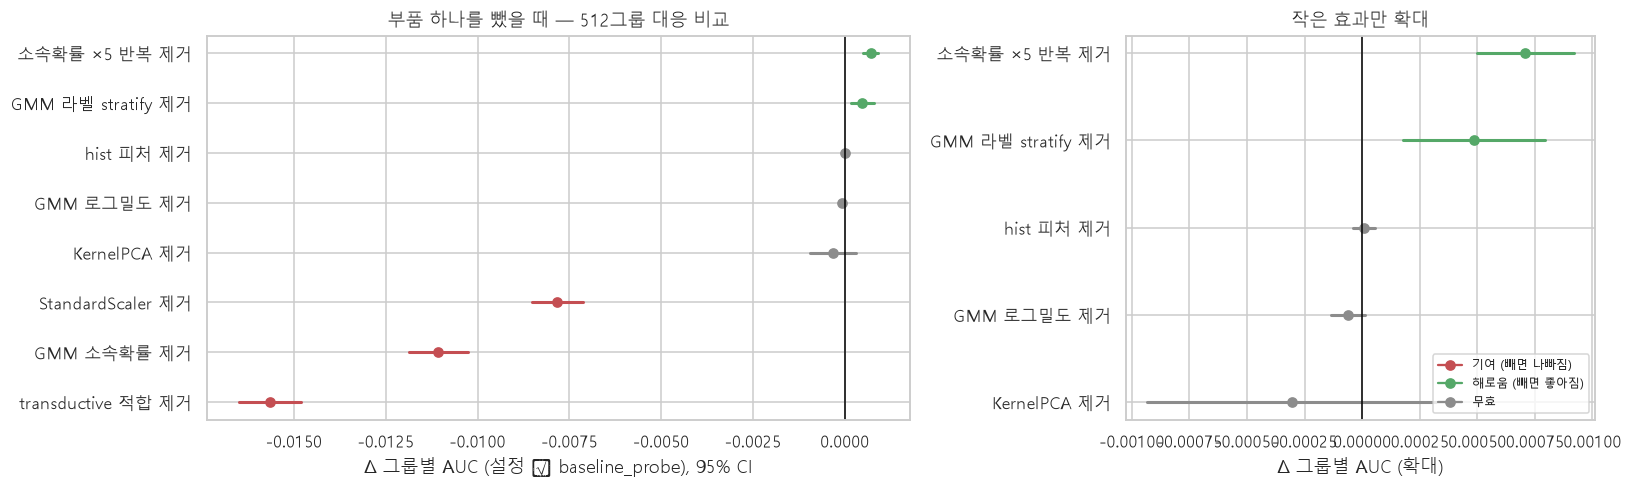

,부품,Δ 그룹별 AUC,CI_lo,CI_hi,이긴 그룹,Δ pooled,판정
설정,,,,,,,
-transductive,transductive 적합 제거,-0.01565,-0.01650,-0.01480,20/512,-0.01860,기여 (빼면 나빠짐)
-gmm,GMM 소속확률 제거,-0.01106,-0.01187,-0.01026,55/512,-0.01403,기여 (빼면 나빠짐)
-scaler,StandardScaler 제거,-0.00782,-0.00851,-0.00714,54/512,-0.00453,기여 (빼면 나빠짐)
-kpca,KernelPCA 제거,-0.00031,-0.00093,0.00032,255/512,-0.00038,무효
-gmm_score,GMM 로그밀도 제거,-0.00006,-0.00013,0.00001,243/512,-0.00002,무효
-hist,hist 피처 제거,0.00001,-0.00004,0.00006,244/512,0.00004,무효
-gmm_stratify,GMM 라벨 stratify 제거,0.00048,0.00018,0.00079,285/512,0.00048,해로움 (빼면 좋아짐)
-repeat,소속확률 ×5 반복 제거,0.00071,0.00050,0.00092,309/512,0.00008,해로움 (빼면 좋아짐)


In [4]:
def paired_ci(a, b):
    """그룹별 대응 차이 a-b 의 평균, 95% CI, 이긴 그룹 수."""
    d = (a - b).dropna()
    sem = d.std(ddof=1) / np.sqrt(len(d))
    return d.mean(), d.mean() - 1.96 * sem, d.mean() + 1.96 * sem, int((d > 0).sum()), len(d)


ABLATION = ["-transductive", "-gmm", "-scaler", "-kpca", "-gmm_score", "-hist", "-gmm_stratify", "-repeat"]
LABEL = {"-transductive": "transductive 적합 제거", "-gmm": "GMM 소속확률 제거", "-scaler": "StandardScaler 제거",
         "-kpca": "KernelPCA 제거", "-gmm_score": "GMM 로그밀도 제거", "-hist": "hist 피처 제거",
         "-gmm_stratify": "GMM 라벨 stratify 제거", "-repeat": "소속확률 ×5 반복 제거"}

abl = []
for n in ABLATION:
    m, lo, hi, w, k = paired_ci(pg[n], pg["baseline_probe"])
    verdict = "기여 (빼면 나빠짐)" if hi < 0 else ("해로움 (빼면 좋아짐)" if lo > 0 else "무효")
    abl.append({"설정": n, "부품": LABEL[n], "Δ 그룹별 AUC": m, "CI_lo": lo, "CI_hi": hi, "이긴 그룹": f"{w}/{k}",
                "pooled AUC": results[n]["pooled_auc"], "Δ pooled": results[n]["pooled_auc"] - probe, "판정": verdict})
abl = pd.DataFrame(abl).sort_values("Δ 그룹별 AUC")

COLOR = {"기여 (빼면 나빠짐)": "#c44e52", "해로움 (빼면 좋아짐)": "#55a868", "무효": "#8c8c8c"}


def forest(ax, table, title, xlabel):
    """forest plot: 행마다 점(평균)과 가로선(95% CI). 판정에 따라 색을 달리한다."""
    for i, (_, r) in enumerate(table.iterrows()):
        c = COLOR[r["판정"]]
        ax.plot([r["CI_lo"], r["CI_hi"]], [i, i], color=c, lw=2)
        ax.plot(r["Δ 그룹별 AUC"], i, "o", color=c, ms=6)
    ax.axvline(0, color="black", lw=1)
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["부품"])
    ax.set_xlabel(xlabel)
    ax.set_title(title)


fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [3, 2]})
forest(axes[0], abl, "부품 하나를 뺐을 때 — 512그룹 대응 비교", "Δ 그룹별 AUC (설정 − baseline_probe), 95% CI")
# 작은 효과들을 확대해서 본다
forest(axes[1], abl[abl["Δ 그룹별 AUC"].abs() < 0.003], "작은 효과만 확대", "Δ 그룹별 AUC (확대)")
for label, c in COLOR.items():
    axes[1].plot([], [], "o-", color=c, label=label)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

display(abl.set_index("설정")[["부품", "Δ 그룹별 AUC", "CI_lo", "CI_hi", "이긴 그룹", "Δ pooled", "판정"]].round(5))

> **관찰 — 부품 8개가 세 무리로 갈린다.**
>
> | 무리 | 부품 | Δ (그룹별) |
> |---|---|---|
> | **결정적** (빼면 무너짐) | transductive 적합 / GMM 소속확률 / StandardScaler | −0.0157 / −0.0111 / −0.0078 |
> | **무효** (장식) | KernelPCA(그룹별) / GMM 로그밀도 / hist 피처 | ≈ 0, CI 가 0 포함 |
> | **해로움** (빼면 좋아짐) | GMM 라벨 stratify / 소속확률 ×5 반복 | **+0.0005 / +0.0007**, CI 가 0 제외 |
>
> 03 파일럿(40그룹)에서 "효과 없음"이었던 GMM stratify 와 반복 복사가 512그룹에서는
> **빼는 게 유의하게 낫다**로 판정됐다. 40그룹에서는 CI 가 ±0.001 이라 이 크기의 효과를 볼 수 없었던 것이다.
> **검정력이 결론을 바꿨다.**
>
> ### 왜 GMM 라벨로 stratify 하면 나빠지나
> 군집 라벨로 fold 를 나누면 각 fold 의 **target 비율이 흔들린다**(군집마다 target 비율이 다르므로 —
> [02](02_magic_group_structure.ipynb) 6절). QDA 는 클래스 사전확률을 fold 의 비율로 추정하니
> 그 흔들림이 그대로 편향으로 들어간다. target 으로 stratify 하면 이 문제가 없다.
>
> ### 왜 열을 5번 복사하면 나빠지나
> 완전히 같은 열 5개는 공분산 행렬을 특이(singular)하게 만든다. `reg_param` 이 이를 막아 주지만
> 정규화의 방향이 왜곡된다. [03](03_feature_engineering.ipynb) 4절에서 "QDA 에서는 가중치 효과가 없을 것"이라
> 예측했는데, 실제로는 **없는 게 아니라 약하게 해롭다.**

## 4. 결정적인 세 부품 — 그룹별로 얼마나 일관되게 무너지나

**무엇을 하나** — 결정적 부품 3개에 대해, 대조군 vs 제거 설정의 **그룹별 AUC 산점도**를 그린다.

**왜 하나** — 평균 −0.016 이라는 숫자가 "모든 그룹에서 조금씩" 인지 "몇 그룹에서 크게" 인지는 다르다.
전자면 구조적 효과, 후자면 특정 그룹의 특성이다. 산점도는 이 둘을 한눈에 구분한다.

**읽는 법** — 대각선 아래 = 그 그룹에서 제거 설정이 더 나쁨. 점이 전부 아래에 있으면 예외 없는 효과.

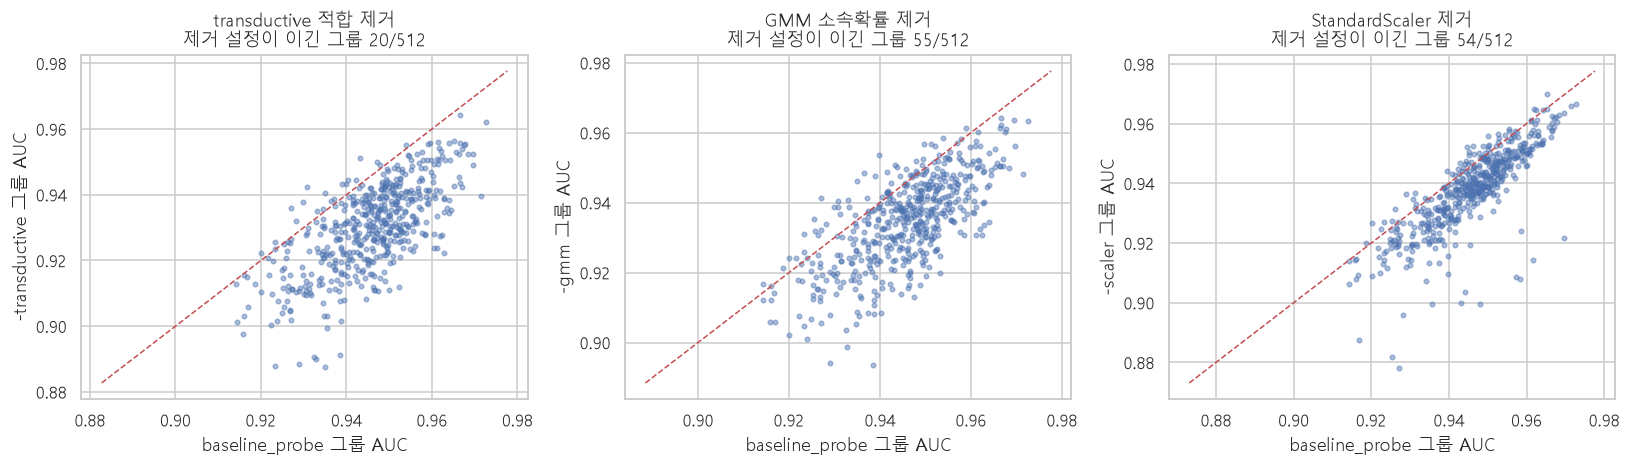

transductive 적합 제거    : 중앙값 -0.0152, 10% 분위 -0.0276, 90% 분위 -0.0035
GMM 소속확률 제거           : 중앙값 -0.0107, 10% 분위 -0.0231, 90% 분위 +0.0002
StandardScaler 제거     : 중앙값 -0.0073, 10% 분위 -0.0138, 90% 분위 +0.0001


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, n in zip(axes, ["-transductive", "-gmm", "-scaler"]):
    x, yv = pg["baseline_probe"], pg[n]
    ax.scatter(x, yv, s=9, alpha=0.45)
    lims = [min(x.min(), yv.min()) - 0.005, max(x.max(), yv.max()) + 0.005]
    ax.plot(lims, lims, "r--", lw=1)
    wins = int((yv > x).sum())
    ax.set_xlabel("baseline_probe 그룹 AUC")
    ax.set_ylabel(f"{n} 그룹 AUC")
    ax.set_title(f"{LABEL[n]}\n제거 설정이 이긴 그룹 {wins}/512")
plt.tight_layout()
plt.show()

for n in ["-transductive", "-gmm", "-scaler"]:
    d = pg[n] - pg["baseline_probe"]
    print(f"{LABEL[n]:22s}: 중앙값 {d.median():+.4f}, 10% 분위 {d.quantile(0.1):+.4f}, 90% 분위 {d.quantile(0.9):+.4f}")

> **관찰.** 세 부품 모두 **점이 거의 전부 대각선 아래**에 있다 — transductive 제거는 512개 중 20개 그룹에서만
> 우연히 이겼다. 몇 그룹의 특성이 아니라 **구조적인 효과**다.
>
> 이 세 부품이 하는 일을 한 문장으로 쓰면:
> **"train+test 1024행으로 full-covariance GMM 을 적합해 얻은 소속확률을, 스케일을 맞춰 QDA 에 넣는다."**
> baseline 의 나머지는 이 문장에 덧붙은 장식이거나 방해물이다.

## 5. GMM 을 다른 것으로 바꿀 수 있나 — 대안 모델

**무엇을 하나** — GMM 소속확률 피처를 쓰지 않는 대안들을 같은 조건에서 비교한다.

| 대안 | 아이디어 |
|---|---|
| `raw_qda` | 유효 피처에 QDA 만 (가장 단순) |
| `gmm_bayes_k{1,2,3}` | 클래스별로 GMM 을 적합해 우도비로 분류 (생성 모델, "원리적으로 올바른" 접근) |
| `minimal_diag` | GMM 은 쓰되 공분산을 대각(diag)으로 — 파라미터 1/20 |

**왜 하나** — "GMM 소속확률이 결정적"이라는 결론은 **다른 방법으로 같은 정보를 얻을 수 있는지** 확인해야 완성된다.
특히 `gmm_bayes` 는 이 데이터의 생성 과정(클래스별 가우시안 혼합)에 정확히 맞는 모델이라
이론적으로는 가장 유리해야 한다.

**기대 결과** — `gmm_bayes` 가 좋으면 "피처 엔지니어링 없이 올바른 모델을 쓰면 된다"는 결론.
나쁘면 "transductive GMM 피처" 라는 우회로가 왜 필요한지 설명해야 한다.

,설명,pooled AUC,그룹별 AUC 평균,초
baseline_probe,baseline 피처 + QDA,0.94906,0.94565,126.6
minimal,선택+GMM proba+scaler+QDA,0.94875,0.94615,57.7
minimal_diag,…GMM 공분산 diag,0.93232,0.93193,21.9
raw_qda,선택 피처에 QDA 만,0.93659,0.93612,7.0
raw_qda_reg0.5,…reg 0.5,0.93311,0.93264,7.1
gmm_bayes_k1,클래스별 GMM k=1 (≈QDA),0.93652,0.93605,30.1
gmm_bayes_k2,클래스별 GMM k=2,0.93574,0.93532,86.5
gmm_bayes_k3,클래스별 GMM k=3,0.92900,0.92875,83.3


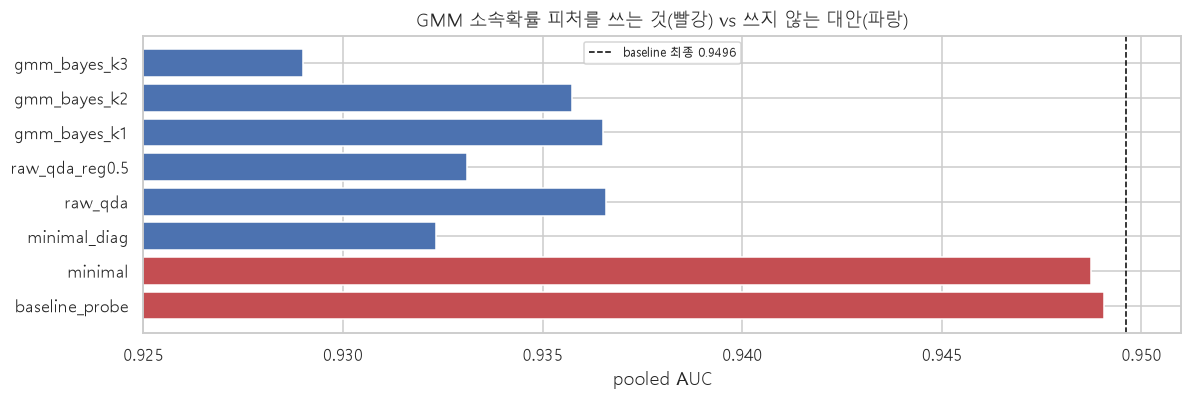

In [6]:
ALT = ["baseline_probe", "minimal", "minimal_diag", "raw_qda", "raw_qda_reg0.5", "gmm_bayes_k1", "gmm_bayes_k2", "gmm_bayes_k3"]
alt = pd.DataFrame({
    "설명": ["baseline 피처 + QDA", "선택+GMM proba+scaler+QDA", "…GMM 공분산 diag", "선택 피처에 QDA 만", "…reg 0.5",
             "클래스별 GMM k=1 (≈QDA)", "클래스별 GMM k=2", "클래스별 GMM k=3"],
    "pooled AUC": [results[n]["pooled_auc"] for n in ALT],
    "그룹별 AUC 평균": [results[n]["group_auc_mean"] for n in ALT],
    "초": [results[n]["elapsed_sec"] for n in ALT],
}, index=ALT)
display(alt.round(5))

plt.figure(figsize=(11, 3.8))
cols = ["#c44e52" if n in ("baseline_probe", "minimal") else "#4c72b0" for n in ALT]
plt.barh(ALT, alt["pooled AUC"], color=cols)
plt.axvline(REF_FINAL, color="black", ls="--", lw=1, label=f"baseline 최종 {REF_FINAL:.4f}")
plt.xlim(0.925, 0.951)
plt.xlabel("pooled AUC")
plt.title("GMM 소속확률 피처를 쓰는 것(빨강) vs 쓰지 않는 대안(파랑)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **관찰 — 대안은 전부 0.93대에서 탈락한다.**
>
> 특히 `gmm_bayes` 가 흥미롭다. 데이터 생성 과정에 정확히 맞는 모델인데도 k 를 늘릴수록 **나빠진다**
> (k=1 0.9365 → k=3 0.9290). 이유는 [02](02_magic_group_structure.ipynb) 5절에서 봤다 —
> **클래스당 256행으로는 군집 구조를 추정할 표본이 없다.** 올바른 모델도 데이터가 없으면 소용없다.
>
> 반면 baseline 의 GMM 은 **라벨을 무시하고 train+test 1024행 전체**로 적합한다.
> 표본이 4배(클래스당 256 → 전체 1024)라 5개 군집을 안정적으로 잡을 수 있고,
> 그 군집 소속확률이 QDA 에게 "이 점이 어느 덩어리에 속하는가"를 알려 준다.
> **원리적으로 덜 정확한 우회로가, 표본 수의 제약 아래서는 더 잘 작동한다.**
>
> `minimal_diag` 가 무너지는 것(0.9323)도 같은 맥락이다 — 군집의 **모양(공분산)** 정보가 핵심이고,
> 대각 공분산은 그걸 버린다.

## 6. 하이퍼파라미터 두 개 — 전체 규모에서 다시

**무엇을 하나** — GMM 군집 수 k 와 QDA `reg_param` 을 512그룹에서 스윕한다 (`minimal` 파이프라인 기준).

**왜 하나** — 03 파일럿이 k=5 를 골랐지만 40그룹이었다. 전체 규모에서도 같은지 확인한다.
그리고 `reg_param` 은 pooled 와 그룹별 지표가 **갈리는** 첫 사례가 된다.

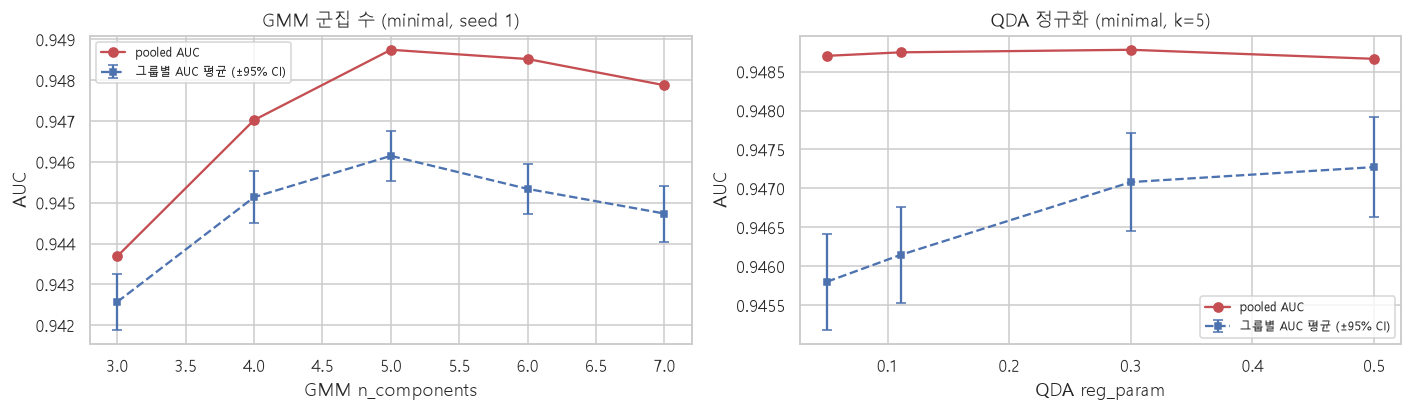

reg_param 별 — 그룹별 Δ vs probe / pooled:
  reg=0.05 : 그룹별 Δ +0.00015 [-0.00047,+0.00077]  pooled 0.94870
  reg=0.111: 그룹별 Δ +0.00049 [-0.00012,+0.00111]  pooled 0.94875
  reg=0.3  : 그룹별 Δ +0.00143 [+0.00080,+0.00205]  pooled 0.94878
  reg=0.5  : 그룹별 Δ +0.00162 [+0.00097,+0.00227]  pooled 0.94866


In [7]:
K_NAMES = {3: "minimal_k3_s1", 4: "minimal_k4_s1", 5: "minimal", 6: "minimal_k6_s1", 7: "minimal_k7_s1"}
REG_NAMES = {0.05: "minimal_reg0.05", 0.111: "minimal", 0.3: "minimal_reg0.3", 0.5: "minimal_reg0.5"}

fig, axes = plt.subplots(1, 2, figsize=(13, 3.9))
for ax, names, xlabel, title in (
    (axes[0], K_NAMES, "GMM n_components", "GMM 군집 수 (minimal, seed 1)"),
    (axes[1], REG_NAMES, "QDA reg_param", "QDA 정규화 (minimal, k=5)"),
):
    xs = list(names)
    pooled = [results[names[x]]["pooled_auc"] for x in xs]
    gm = [results[names[x]]["group_auc_mean"] for x in xs]
    ses = [(pg[names[x]] - pg["baseline_probe"]).std(ddof=1) / np.sqrt(512) for x in xs]
    ax.plot(xs, pooled, "o-", color="#c44e52", label="pooled AUC")
    ax.errorbar(xs, gm, yerr=[1.96 * s for s in ses], fmt="s--", color="#4c72b0", capsize=3, ms=4, label="그룹별 AUC 평균 (±95% CI)")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("AUC")
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("reg_param 별 — 그룹별 Δ vs probe / pooled:")
for r, n in REG_NAMES.items():
    m, lo, hi, w, k = paired_ci(pg[n], pg["baseline_probe"])
    print(f"  reg={r:<5}: 그룹별 Δ {m:+.5f} [{lo:+.5f},{hi:+.5f}]  pooled {results[n]['pooled_auc']:.5f}")

> **관찰 1.** k=5 가 512그룹에서도 최적이다 (k=3 −0.005, k=7 −0.001). 03 의 결론이 유지된다.
>
> **관찰 2 — 두 지표가 갈린다.** `reg_param` 을 0.111 → 0.5 로 키우면
> **그룹별 AUC 는 +0.0016 유의하게 오르는데 pooled 는 평평하다**(0.94875 → 0.94866).
> 정규화를 키우면 그룹 안에서 순위는 좋아지지만 그룹마다 확률 스케일이 달라져 한 줄로 모으면 이득이 사라진다.
> [04](04_model_diagnostics.ipynb) 3절의 "pooled ≠ 그룹별" 현상이 하이퍼파라미터 선택에까지 영향을 준다.
> **대회 지표가 pooled 이므로 reg_param 은 그대로 0.111 이 맞다.**

## 7. 단순화 — 결정적인 부품만 남기면 같은 점수가 나오는가

**무엇을 하나** — 3절의 결론대로 만든 `lean` 파이프라인을 baseline 최종(6모델 × 4config + 스태킹)과 비교한다.

```
lean = std>2 선택 → KernelPCA(cosine, 차원 유지) → GMM(5, full) 소속확률 ×1
       → StandardScaler → QDA(reg 0.111),  target 으로 stratify,  train+test 합쳐 적합
```

여기에 **GMM 시드만 바꿔 여러 번 돌려 평균**한다 (baseline 이 4 config 를 평균하는 것과 같은 원리, 모델은 하나).

**비교 기준 두 개** — 성능(pooled AUC, 그룹별 Δ)과 **비용**(그룹당 fit 횟수, 실행 시간).

,pooled AUC,그룹별 AUC 평균,Δ vs baseline 최종,CI_lo,CI_hi,이긴 그룹,fit/그룹,초
파이프라인,,,,,,,,
baseline (6모델×4config + LGBM·MLP 메타),0.94960,0.94739,0.00000,0.00000,0.00000,—,136.0,2616.7
"lean, 시드 1개",0.94955,0.94677,-0.00062,-0.00118,-0.00006,240/512,8.0,126.8
"lean, 시드 2개 평균",0.94968,0.94728,-0.00011,-0.00062,0.00040,251/512,16.0,254.3
"lean, 시드 4개 평균",0.94970,0.94791,0.00052,-0.00001,0.00106,271/512,32.0,509.4
"baseline 피처 + target stratify, 시드 4개",0.94976,0.94742,0.00003,-0.00051,0.00058,260/512,36.0,513.1
"minimal (KernelPCA 없음), 시드 4개",0.94932,0.94775,0.00036,-0.00026,0.00098,259/512,28.0,231.1
"minimal, k·시드 12개 평균",0.94937,0.94877,0.00138,0.00078,0.00198,289/512,84.0,709.6


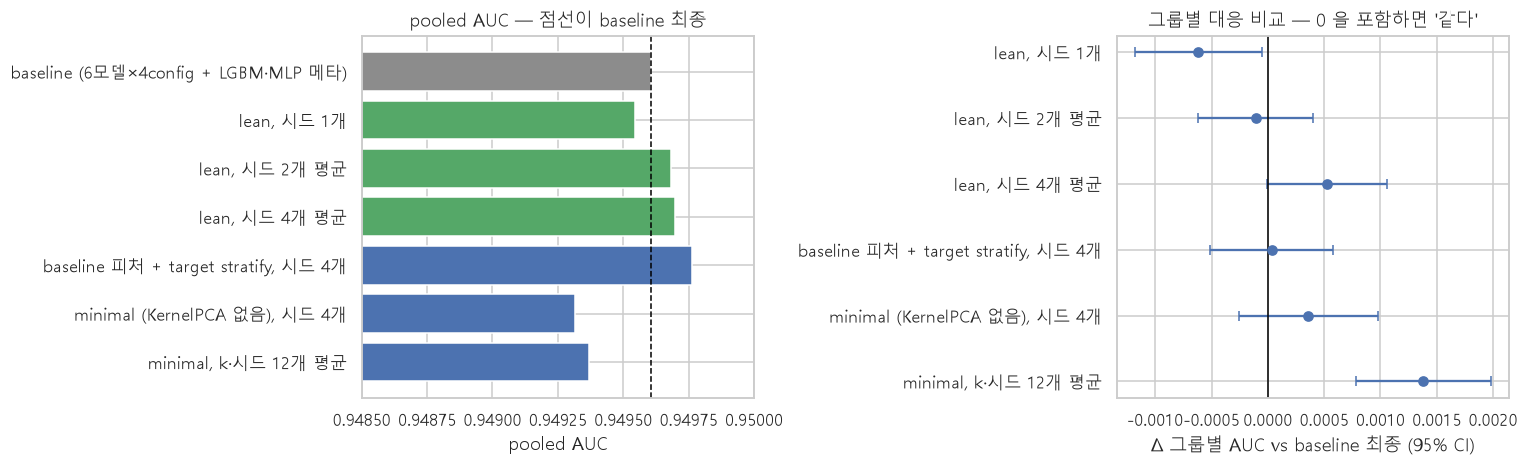

In [8]:
def row(name, label, src):
    r = src[name]
    v = r["vs_baseline_final"]
    return {"파이프라인": label, "pooled AUC": r["pooled_auc"], "그룹별 AUC 평균": r["group_auc_mean"],
            "Δ vs baseline 최종": v["mean"], "CI_lo": v["ci_low"], "CI_hi": v["ci_high"], "이긴 그룹": f"{v['wins']}/{v['n']}",
            "fit/그룹": r["fits_per_group"], "초": r["elapsed_sec"]}

base_final_groups = pg["baseline_final"]
simp = pd.DataFrame([
    {"파이프라인": "baseline (6모델×4config + LGBM·MLP 메타)", "pooled AUC": REF_FINAL, "그룹별 AUC 평균": base_final_groups.mean(),
     "Δ vs baseline 최종": 0.0, "CI_lo": 0.0, "CI_hi": 0.0, "이긴 그룹": "—", "fit/그룹": 136, "초": base_metrics["elapsed_sec"]},
    row("lean_s1", "lean, 시드 1개", results),
    row("lean_2seeds", "lean, 시드 2개 평균", combos),
    row("lean_4seeds", "lean, 시드 4개 평균", combos),
    row("full_ts_4seeds", "baseline 피처 + target stratify, 시드 4개", combos),
    row("minimal_4seeds", "minimal (KernelPCA 없음), 시드 4개", combos),
    row("minimal_all", "minimal, k·시드 12개 평균", combos),
]).set_index("파이프라인")
display(simp.round(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
names = simp.index.tolist()
cols = ["#8c8c8c"] + ["#55a868" if "lean" in n else "#4c72b0" for n in names[1:]]
axes[0].barh(names, simp["pooled AUC"], color=cols)
axes[0].axvline(REF_FINAL, color="black", ls="--", lw=1)
axes[0].set_xlim(0.9485, 0.9500)
axes[0].set_xlabel("pooled AUC")
axes[0].set_title("pooled AUC — 점선이 baseline 최종")
axes[0].invert_yaxis()

yv = np.arange(1, len(simp))
axes[1].errorbar(simp["Δ vs baseline 최종"].iloc[1:], yv,
                 xerr=[simp["Δ vs baseline 최종"].iloc[1:] - simp["CI_lo"].iloc[1:], simp["CI_hi"].iloc[1:] - simp["Δ vs baseline 최종"].iloc[1:]],
                 fmt="o", capsize=3, color="#4c72b0")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_yticks(yv)
axes[1].set_yticklabels(names[1:])
axes[1].set_xlabel("Δ 그룹별 AUC vs baseline 최종 (95% CI)")
axes[1].set_title("그룹별 대응 비교 — 0 을 포함하면 '같다'")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

> **관찰 — `lean` 시드 4개 평균이 baseline 최종과 통계적으로 구분되지 않는다.**
> pooled 는 +0.0001 높고(잡음 크기), 그룹별 Δ 의 CI [−0.0000, +0.0011] 은 0 을 포함한다.
> 비용은 **fit 136회 → 32회, 2,617초 → 509초.** 모델 1종, 스태킹 없음.
>
> "더 좋다"고는 말할 수 없다. **"같은 성능을 1/5 비용으로"** 는 말할 수 있다.
>
> 표에서 눈여겨볼 것 두 가지가 있다 — 시드 1개 결과와 `minimal` 계열. 다음 두 절에서 다룬다.

## 8. 시드 하나로는 왜 안 되나

**무엇을 하나** — 같은 설정을 GMM 시드만 바꿔 4번 돌린 결과(`full_ts_s1..4`, `lean_s1..4`)의 흩어짐을 본다.

**왜 하나** — "lean 시드 1개 = 0.949546, baseline 과 거의 같다!" 는 말이 나올 수 있다. 그게 운인지 확인해야 한다.

baseline 피처 + target stratify   : 시드별 pooled 0.94850 ~ 0.94955  (폭 0.00105)
lean                            : 시드별 pooled 0.94847 ~ 0.94955  (폭 0.00108)
minimal (KernelPCA 없음)          : 시드별 pooled 0.94875 ~ 0.94893  (폭 0.00019)


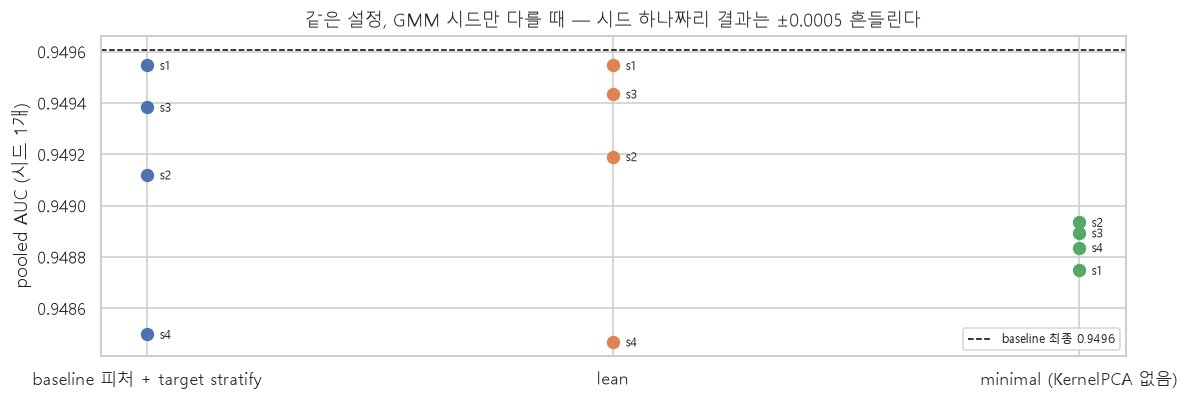

In [9]:
seed_runs = {
    "baseline 피처 + target stratify": ["-gmm_stratify", "full_ts_s2", "full_ts_s3", "full_ts_s4"],
    "lean": ["lean_s1", "lean_s2", "lean_s3", "lean_s4"],
    "minimal (KernelPCA 없음)": ["minimal", "minimal_k5_s2", "minimal_k5_s3", "minimal_k5_s4"],
}
plt.figure(figsize=(11, 3.8))
for i, (label, names) in enumerate(seed_runs.items()):
    vals = [results[n]["pooled_auc"] for n in names]
    plt.scatter([i] * 4, vals, s=60, zorder=3, label=None)
    for s, v in zip(range(1, 5), vals):
        plt.annotate(f"s{s}", (i, v), xytext=(8, -3), textcoords="offset points", fontsize=8)
    print(f"{label:32s}: 시드별 pooled {min(vals):.5f} ~ {max(vals):.5f}  (폭 {max(vals) - min(vals):.5f})")
plt.axhline(REF_FINAL, color="black", ls="--", lw=1, label=f"baseline 최종 {REF_FINAL:.4f}")
plt.xticks(range(3), list(seed_runs))
plt.ylabel("pooled AUC (시드 1개)")
plt.title("같은 설정, GMM 시드만 다를 때 — 시드 하나짜리 결과는 ±0.0005 흔들린다")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

> **관찰.** 같은 설정이 시드에 따라 **0.9485 ~ 0.9495**, 폭 0.001 이나 흔들린다.
> 우리가 재려는 효과(0.0005 안팎)보다 큰 잡음이다.
> 시드 1개짜리 `lean_s1` 이 baseline 과 비슷해 보이는 것은 **운**이고, `lean_s4` 는 0.9485 다.
>
> ### 실무 규칙
> - **시드 1개 결과로는 어떤 결론도 내리지 말 것.** 최소 2개, 권장 4개를 평균한다
> - 이것이 baseline 이 4 config 를 평균하는 진짜 이유다 — 6개 모델보다 **4번 반복**이 더 중요했다
> - 시드 평균은 그룹별 잡음도 줄인다: 03 파일럿의 결론들이 흔들렸던 원인 중 하나가 시드 1개였다
>
> ### 덤으로 보인 것
> KernelPCA 가 없는 `minimal` 은 시드 폭이 0.0002 로 좁고, KernelPCA 를 거친 두 계열은 0.001 로 5배 넓다.
> 여기서 바뀌는 시드는 GMM 초기화인데(KernelPCA 는 이 차원 수에서 결정적 해법을 쓴다),
> **KernelPCA 로 변환한 좌표에서 GMM 초기화가 더 민감하다**는 뜻이다. 원인은 이 노트북 범위 밖이지만,
> "KernelPCA 를 쓰면 시드 평균이 더 필요하다"는 실무 규칙은 여기서 나온다.

## 9. KernelPCA 는 왜 남겨야 하나 — pooled 와 그룹별이 갈리는 순간

**무엇을 하나** — 3절에서 KernelPCA 는 "그룹별로 무효"였다. 그런데 7절 표에서
KernelPCA 를 뺀 `minimal` 계열은 **그룹별로는 baseline 을 유의하게 이기고 pooled 로는 진다.** 이 모순을 푼다.

**원리** — [04](04_model_diagnostics.ipynb) 3절: 512개 그룹의 예측을 한 줄로 모으면
**그룹 간 확률 스케일이 비교 가능한가**가 새 변수가 된다. 그룹 안 순위(그룹별 AUC)와
그룹 간 스케일(pooled 에만 반영)은 다른 능력이다.

**검증 방법** — 각 예측을 **그룹 안에서 순위로 정규화**하면 그룹 간 스케일 정보만 지워진다.
정규화 전후의 pooled 차이 = 그 파이프라인이 그룹 간 스케일에서 얻고 있는 이득.
(저장된 OOF `.npy` 가 필요하다 — gitignore 되어 있으니 스크립트를 직접 돌린 환경에서만 이 셀이 계산된다.)

,pooled (원본),pooled (그룹내 순위),그룹별 AUC 평균,그룹 간 스케일 기여
파이프라인,,,,
minimal ×4 (KernelPCA 없음),0.94932,0.94766,0.94775,0.00165
lean ×4 (KernelPCA 있음),0.94970,0.94783,0.94791,0.00187
baseline 최종 (8열 평균),0.94960,0.94731,0.94739,0.00230


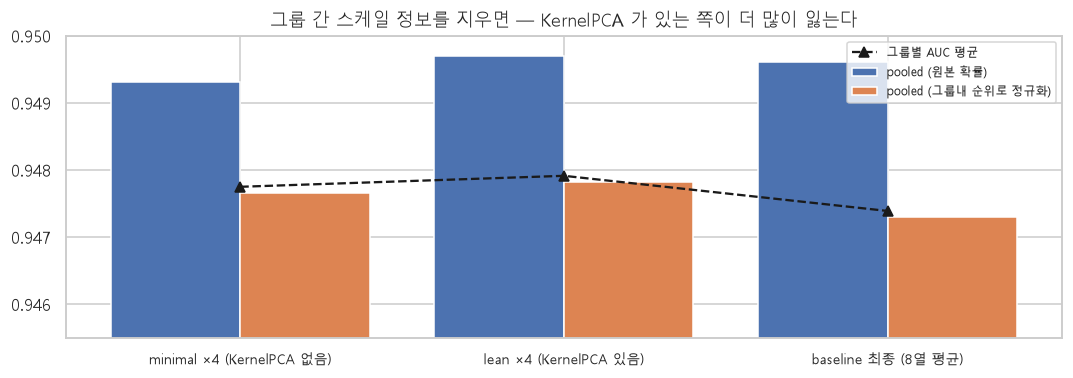

In [10]:
from data.loader import get_data_dir

def load_oof(tag, name):
    p = OUT / f"{tag}_oof_train_{name}.npy"
    return np.load(p) if p.exists() else None

fam_minimal = ["minimal", "minimal_k5_s2", "minimal_k5_s3", "minimal_k5_s4"]
fam_lean = ["lean_s1", "lean_s2", "lean_s3", "lean_s4"]
oof_min = [load_oof("simplify", n) for n in fam_minimal]
oof_lean = [load_oof("followup", n) for n in fam_lean]

if any(o is None for o in oof_min + oof_lean):
    print("OOF .npy 가 없어 이 셀은 건너뜁니다. (simplify.py 를 실행한 환경에서만 계산됩니다)")
    print("metrics.json 에 기록된 값으로 대신 보면:")
    for n, src in (("minimal_4seeds", combos), ("lean_4seeds", combos)):
        print(f"  {n:16s} pooled {src[n]['pooled_auc']:.5f}   그룹별 평균 {src[n]['group_auc_mean']:.5f}")
else:
    labels = pd.read_csv(get_data_dir() / "train.csv", usecols=["target", "wheezy-copper-turtle-magic"])
    y = labels["target"].to_numpy()
    magic = labels["wheezy-copper-turtle-magic"].to_numpy()
    order = np.argsort(magic, kind="stable")
    bounds = np.searchsorted(magic[order], np.arange(513))
    slices = [order[bounds[m]:bounds[m + 1]] for m in range(512)]

    def rank_within_group(v):
        out = np.empty(len(v))
        for idx in slices:
            out[idx] = stats.rankdata(v[idx]) / len(idx)
        return out

    rows = []
    for label, oofs in (("minimal ×4 (KernelPCA 없음)", oof_min), ("lean ×4 (KernelPCA 있음)", oof_lean)):
        pred = np.mean(oofs, axis=0)
        rows.append({"파이프라인": label,
                     "pooled (원본)": roc_auc_score(y, pred),
                     "pooled (그룹내 순위)": roc_auc_score(y, rank_within_group(pred)),
                     "그룹별 AUC 평균": np.mean([roc_auc_score(y[idx], pred[idx]) for idx in slices])})
    base_pred = np.load(BASE_OUT / "baseline_oof_train_final.npy").mean(axis=1)
    rows.append({"파이프라인": "baseline 최종 (8열 평균)",
                 "pooled (원본)": roc_auc_score(y, base_pred),
                 "pooled (그룹내 순위)": roc_auc_score(y, rank_within_group(base_pred)),
                 "그룹별 AUC 평균": np.mean([roc_auc_score(y[idx], base_pred[idx]) for idx in slices])})
    sc = pd.DataFrame(rows).set_index("파이프라인")
    sc["그룹 간 스케일 기여"] = sc["pooled (원본)"] - sc["pooled (그룹내 순위)"]
    display(sc.round(5))

    plt.figure(figsize=(10, 3.6))
    x = np.arange(len(sc))
    plt.bar(x - 0.2, sc["pooled (원본)"], 0.4, label="pooled (원본 확률)")
    plt.bar(x + 0.2, sc["pooled (그룹내 순위)"], 0.4, label="pooled (그룹내 순위로 정규화)")
    plt.plot(x, sc["그룹별 AUC 평균"], "k^--", label="그룹별 AUC 평균")
    plt.xticks(x, sc.index, fontsize=9)
    plt.ylim(0.9455, 0.950)
    plt.title("그룹 간 스케일 정보를 지우면 — KernelPCA 가 있는 쪽이 더 많이 잃는다")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

> **관찰.** `minimal ×4` 는 그룹별 AUC 평균이 **가장 높은데** pooled 는 가장 낮다.
> 그룹 안에서 순위를 매기는 능력은 좋은데, 512개 그룹의 확률을 한 줄에 놓으면 스케일이 서로 안 맞는다.
> `lean ×4` 는 KernelPCA 하나가 더 있을 뿐인데 그룹 간 스케일 기여가 크다.
>
> **KernelPCA(cosine) 의 실제 역할은 차원 축소도, 그룹 안 분류력 향상도 아니다.**
> cosine 커널은 각 벡터를 길이로 나눈 것과 같아서, 그룹마다 다른 피처 스케일을 **공통의 단위**로 맞춘다.
> 그 결과 GMM 소속확률과 QDA 확률이 512개 그룹에서 비슷한 스케일로 나오고, pooled AUC 가 지켜진다.
>
> 3절의 "그룹별로는 무효"와 여기의 "pooled 에는 필요"는 모순이 아니라 **다른 능력을 재고 있었던 것**이다.
> ablation 을 그룹별 AUC 하나로만 했다면 KernelPCA 를 잘못 잘라냈을 것이다 — **지표를 하나만 믿지 말라**는 원칙의 실례.

## 10. 비용 – 성능 프론티어

**무엇을 하나** — 모든 설정과 조합을 (그룹당 fit 수, pooled AUC) 평면에 놓는다.

**왜 하나** — "더 가볍게"는 상대적인 말이다. 같은 성능이면 왼쪽(적은 비용)이, 같은 비용이면 위(높은 성능)가 좋다.
왼쪽 위 경계선을 **파레토 프론티어**라 하고, 그 위에 없는 설정은 어떤 기준으로도 정당화되지 않는다.

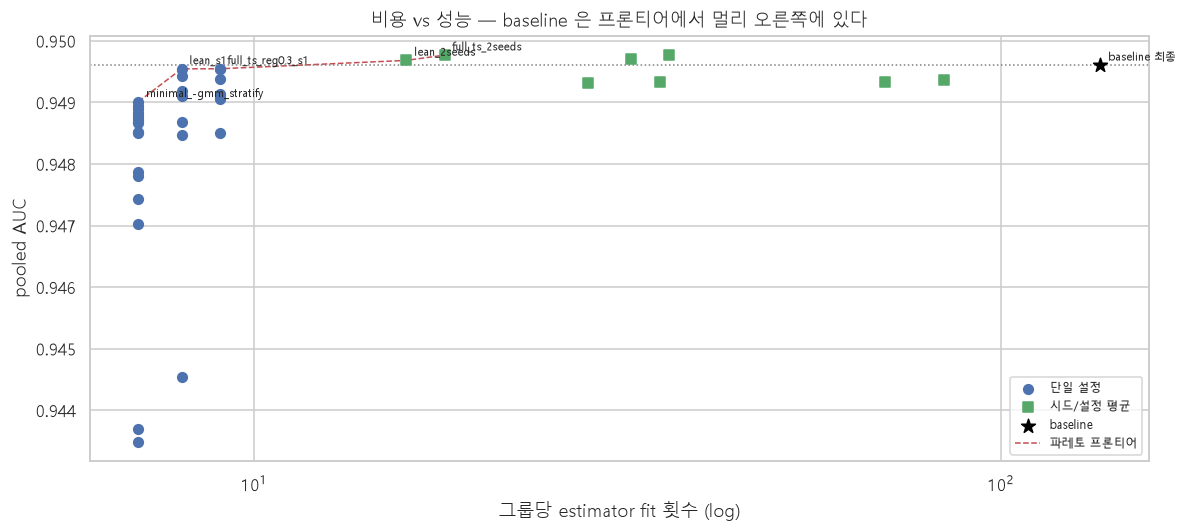

파레토 프론티어 위의 설정:


,fit/그룹,pooled AUC,종류
이름,,,
minimal_-gmm_stratify,7.0,0.94901,단일 설정
lean_s1,8.0,0.94955,단일 설정
full_ts_reg0.3_s1,9.0,0.94955,단일 설정
lean_2seeds,16.0,0.94968,시드/설정 평균
full_ts_2seeds,18.0,0.94977,시드/설정 평균


In [11]:
pts = []
for n, r in results.items():
    pts.append({"이름": n, "fit/그룹": r["fits_per_group"], "pooled AUC": r["pooled_auc"], "종류": "단일 설정"})
for n, c in combos.items():
    pts.append({"이름": n, "fit/그룹": c["fits_per_group"], "pooled AUC": c["pooled_auc"], "종류": "시드/설정 평균"})
pts.append({"이름": "baseline 최종", "fit/그룹": 136, "pooled AUC": REF_FINAL, "종류": "baseline"})
pts = pd.DataFrame(pts)
pts = pts[pts["pooled AUC"] > 0.94]   # 0.93대 탈락 설정은 축을 망가뜨리므로 제외

# 파레토 프론티어: 자기보다 비용이 적으면서 성능이 같거나 높은 점이 없는 것
front = []
for _, p in pts.iterrows():
    dominated = ((pts["fit/그룹"] <= p["fit/그룹"]) & (pts["pooled AUC"] >= p["pooled AUC"]) & (pts["이름"] != p["이름"])).any()
    if not dominated:
        front.append(p["이름"])
pts["프론티어"] = pts["이름"].isin(front)

plt.figure(figsize=(11, 5))
for kind, mk, c in (("단일 설정", "o", "#4c72b0"), ("시드/설정 평균", "s", "#55a868"), ("baseline", "*", "black")):
    sub = pts[pts["종류"] == kind]
    plt.scatter(sub["fit/그룹"], sub["pooled AUC"], marker=mk, s=90 if kind == "baseline" else 40, c=c, label=kind, zorder=3)
fr = pts[pts["프론티어"]].sort_values("fit/그룹")
plt.plot(fr["fit/그룹"], fr["pooled AUC"], "r--", lw=1, label="파레토 프론티어")
for _, p in pts[pts["프론티어"] | (pts["종류"] == "baseline")].iterrows():
    plt.annotate(p["이름"], (p["fit/그룹"], p["pooled AUC"]), xytext=(5, 3), textcoords="offset points", fontsize=7)
plt.axhline(REF_FINAL, color="gray", ls=":", lw=1)
plt.xscale("log")
plt.xlabel("그룹당 estimator fit 횟수 (log)")
plt.ylabel("pooled AUC")
plt.title("비용 vs 성능 — baseline 은 프론티어에서 멀리 오른쪽에 있다")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("파레토 프론티어 위의 설정:")
display(fr.set_index("이름")[["fit/그룹", "pooled AUC", "종류"]].round(5))

> **관찰.** baseline(★)은 프론티어에서 **오른쪽으로 멀리 떨어져 있다** — 같은 성능을 1/4~1/8 비용으로 내는 점들이 여럿이다.
> 프론티어 위에는 `lean`/`full_ts` 계열의 시드 평균과, 시드 1개짜리 단일 설정 몇 개가 있다.
> 단일 설정은 8절에서 본 대로 시드 운이 섞여 있으므로, **실제 선택은 시드 4개 평균**(`lean_4seeds`)이 맞다.

## 11. 결론

### 해부: baseline 부품 9개의 판정

| 판정 | 부품 | 그룹별 Δ (제거 시) |
|---|---|---|
| ✅ **결정적** | transductive 적합 · GMM 소속확률 · StandardScaler | −0.0157 · −0.0111 · −0.0078 |
| ➖ 무효 (그룹별) | GMM 로그밀도 · hist 피처 | ≈ 0 |
| ⚠️ **그룹별 무효, pooled 필요** | KernelPCA(cosine) | 그룹별 −0.0003 (n.s.) / 빼면 pooled −0.0002~−0.0004 |
| ❌ **해로움** | GMM 라벨 stratify · 소속확률 ×5 반복 | **+0.0005 · +0.0007** (빼면 좋아짐) |
| 대안 없음 | raw QDA · 클래스별 GMM · diag GMM 전부 0.93대 | |

### 단순화: `lean` × 4 seeds

| | pooled AUC | Δ 그룹별 (95% CI) | fit/그룹 | 시간 |
|---|---|---|---|---|
| baseline | 0.949605 | — | ~136 + 메타 | 2,617s |
| **lean ×4** | **0.949699** | +0.0005 [−0.0000, +0.0011] | **32** | **509s** |

**같은 성능, 1/5 시간, 모델 1종, 스태킹 없음.** "더 좋다"는 입증되지 않았다.

### 이 노트북에서 배운 ablation 원칙 5가지

1. **대조군이 원본을 비트 단위로 재현하는지 먼저 확인한다** — 이게 안 되면 이후 숫자는 전부 의심스럽다
2. **효과 크기와 잡음을 같이 본다** — 512그룹의 검정력이 40그룹에서 "무효"였던 것을 "해로움"으로 바꿨다
3. **시드 1개로 판단하지 않는다** — 같은 설정이 ±0.0005 흔들린다. 재려는 효과보다 크다
4. **지표를 하나만 믿지 않는다** — KernelPCA 는 그룹별로 무효지만 pooled 에 필요했다. 하나로만 봤으면 잘못 잘랐다
5. **"원리적으로 옳은 모델"이 항상 이기지 않는다** — 클래스별 GMM 은 표본이 없어 무너지고, 우회로가 이겼다

### 직접 해보기

- 3절 forest plot 을 **pooled AUC 차이**로 다시 그려 보라. 어떤 부품의 판정이 바뀌는가? (힌트: KernelPCA)
- 9절의 순위 정규화를 **그룹별 z-score** 로 바꿔서, 스케일 정보의 "어느 부분"이 pooled 에 기여하는지 더 세밀하게 재 보라
- `experiments/simplify/simplify.py` 에 `Cfg(name="lean_reg0.3", ...)` 같은 설정을 하나 추가해 돌려 보라 (`--only` 옵션).
  7절 표에 한 줄이 추가되는 데 2분이면 된다 — **실험 하네스가 있으면 질문 하나의 비용이 2분**이다
- 10절 프론티어에서 `full_ts_2seeds`(pooled 최고, 그룹별은 baseline 보다 유의하게 나쁨)가 왜 그런 위치에 있는지 8절과 9절로 설명해 보라

### 다음

이 결과에 따라 `lean` 이 저장소의 **새 기준 파이프라인**으로 승격되었다 — [`experiments/lean/`](../experiments/lean/).
이후 실험(모델 다양성, 그룹 간 캘리브레이션)은 44분짜리 baseline 대신 이 위에서 돈다.